In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

df = pd.read_csv("../data/processed/historical_data.csv", parse_dates=["timestamp"])

print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
df.describe()

Shape: (8304, 12)

Column dtypes:
timestamp                datetime64[ns]
city                             object
latitude                        float64
longitude                       float64
temperature_2m_c                float64
relative_humidity_pct             int64
precipitation_mm                float64
wind_speed_10m_kmh              float64
pm2_5_ugm3                      float64
pm10_ugm3                       float64
carbon_monoxide_ugm3            float64
nitrogen_dioxide_ugm3           float64
dtype: object

Missing values:
timestamp                0
city                     0
latitude                 0
longitude                0
temperature_2m_c         0
relative_humidity_pct    0
precipitation_mm         0
wind_speed_10m_kmh       0
pm2_5_ugm3               0
pm10_ugm3                0
carbon_monoxide_ugm3     0
nitrogen_dioxide_ugm3    0
dtype: int64

Basic stats:


,timestamp,latitude,longitude,temperature_2m_c,relative_humidity_pct,precipitation_mm,wind_speed_10m_kmh,pm2_5_ugm3,pm10_ugm3,carbon_monoxide_ugm3,nitrogen_dioxide_ugm3
count,8304,8304.000000,8304.000000,8304.000000,8304.000000,8304.000000,8304.000000,8304.000000,8304.000000,8304.000000,8304.000000
mean,2026-03-28 11:30:00,-6.733150,109.798850,27.725084,77.640053,0.289463,7.469003,50.368341,51.223483,1790.365968,45.508394
min,2026-01-01 00:00:00,-7.257500,106.845600,22.500000,33.000000,0.000000,0.000000,5.200000,5.500000,35.000000,2.700000
25%,2026-02-13 05:45:00,-7.257500,106.845600,25.700000,69.000000,0.000000,4.300000,25.600000,26.600000,728.000000,22.700000
50%,2026-03-28 11:30:00,-6.733150,109.798850,27.400000,80.000000,0.000000,6.800000,39.900000,40.700000,1306.000000,37.400000
75%,2026-05-10 17:15:00,-6.208800,112.752100,29.500000,88.000000,0.100000,10.200000,67.500000,68.500000,2254.750000,62.700000
max,2026-06-22 23:00:00,-6.208800,112.752100,36.000000,100.000000,27.800000,25.500000,207.700000,207.700000,17354.000000,193.400000
std,NaN,0.524382,2.953428,2.520983,13.139351,0.958585,4.050106,32.690362,32.664894,1627.409926,30.043553


<function matplotlib.pyplot.show(close=None, block=None)>

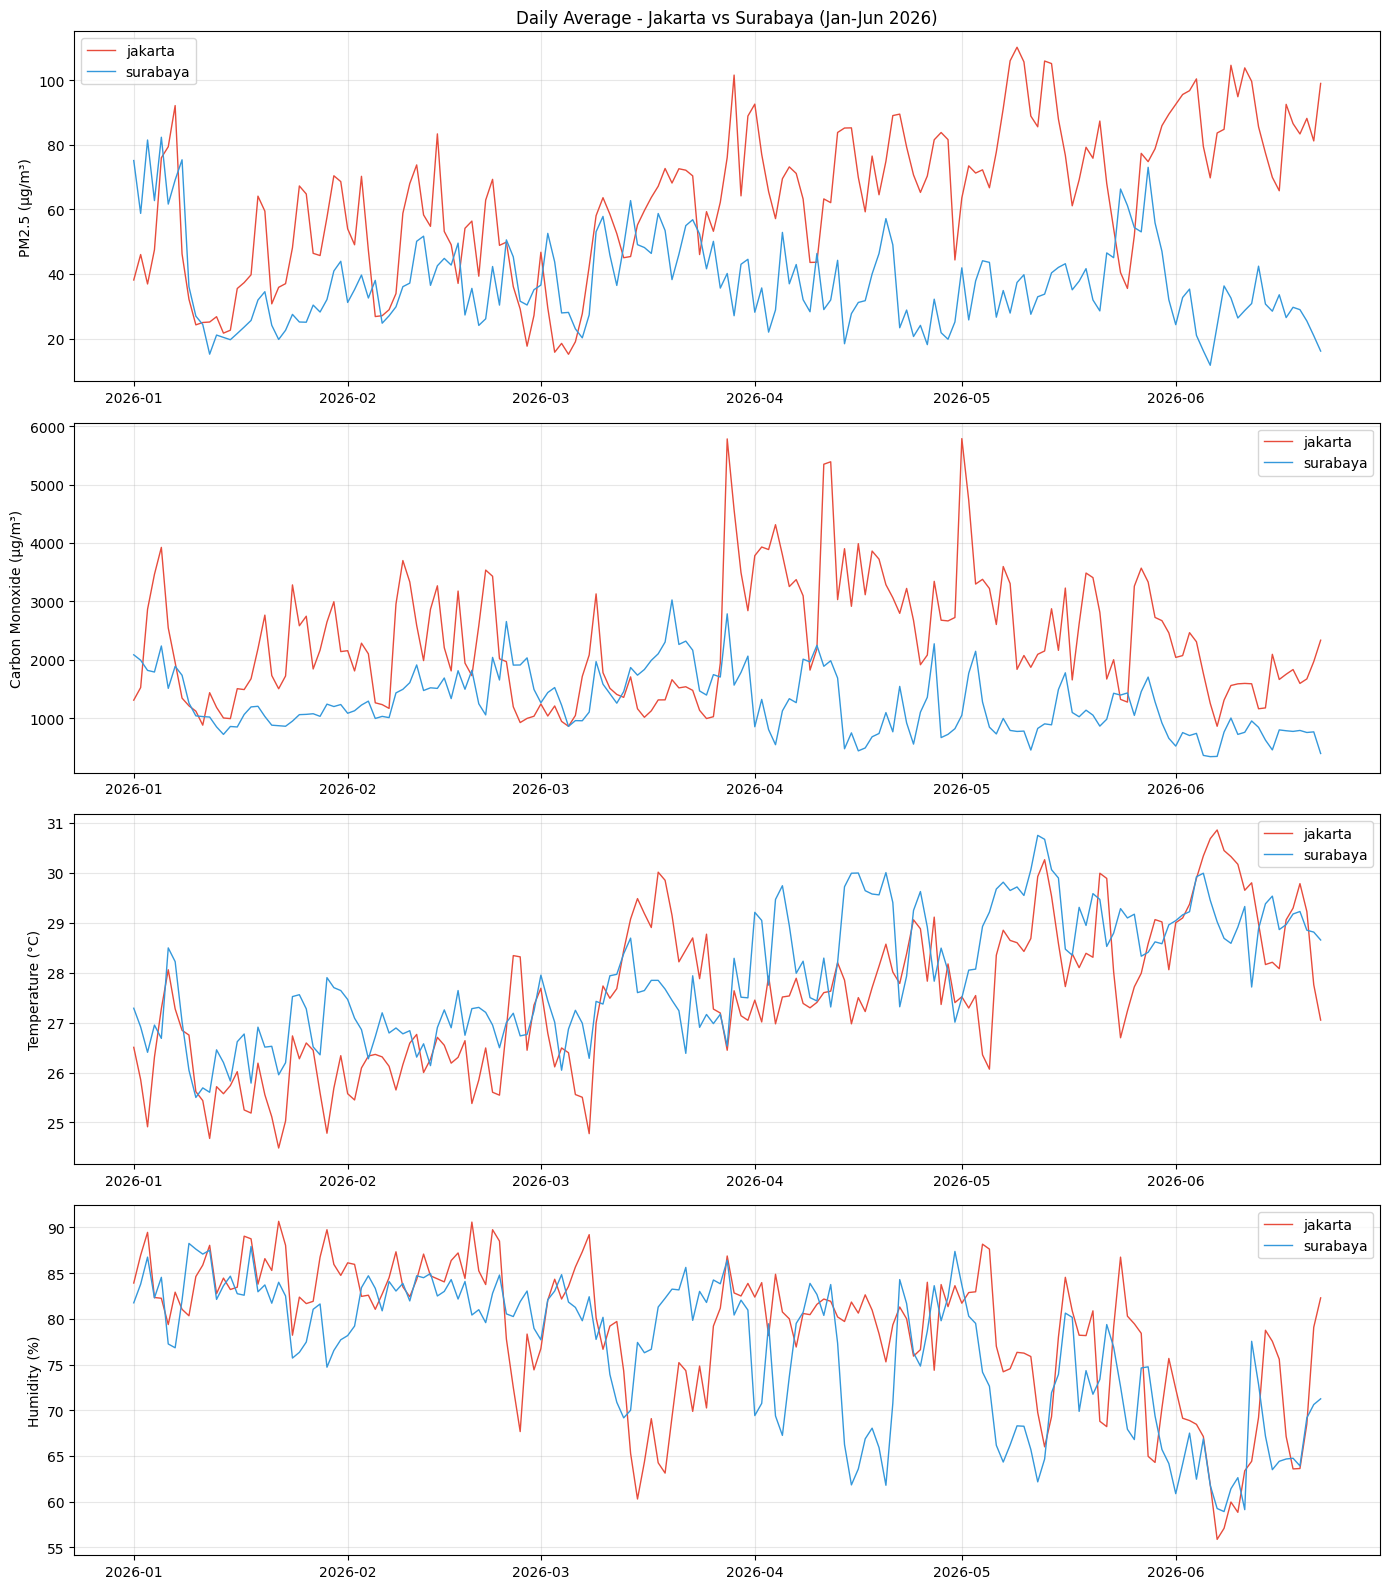

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)

metrics = [
    ("pm2_5_ugm3",  "PM2.5 (µg/m³)"),
    ("carbon_monoxide_ugm3",  "Carbon Monoxide (µg/m³)"),
    ("temperature_2m_c",  "Temperature (°C)"),
    ("relative_humidity_pct",  "Humidity (%)"),
]

cities = df["city"].unique()
colors = {"jakarta": "#e74c3c", "surabaya": "#3498db"}

for ax, (col, label) in zip(axes, metrics):
    for city in cities:
        subset = df[df["city"] == city].set_index("timestamp")
        daily = subset[col].resample("D").mean()
        ax.plot(daily.index, daily.values, label=city, color=colors[city], linewidth=1)
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_title("Daily Average - Jakarta vs Surabaya (Jan-Jun 2026)")
plt.tight_layout()
plt.show

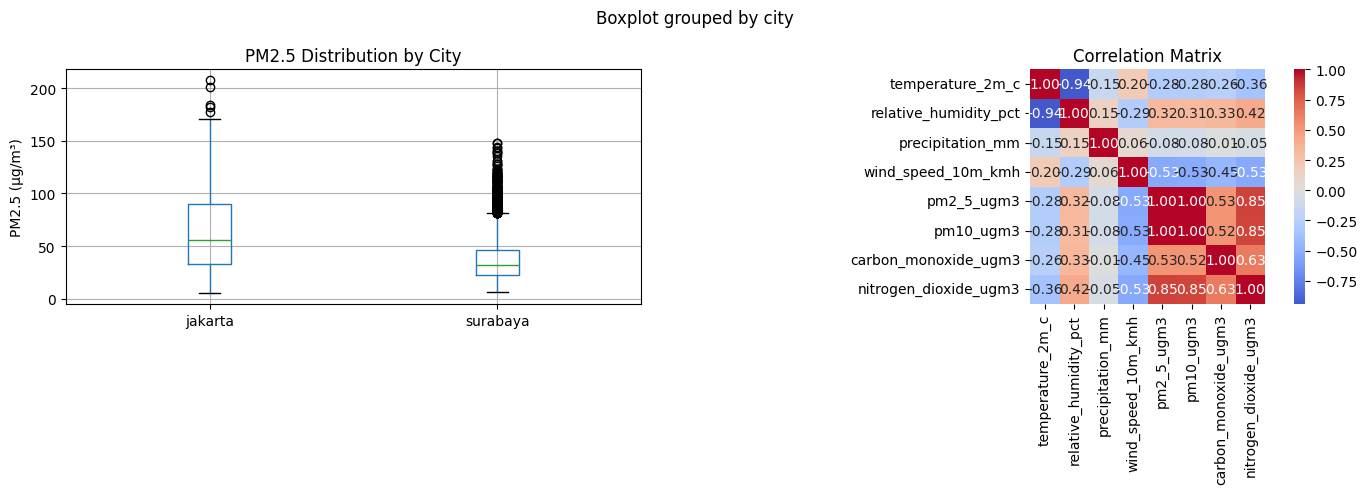

In [5]:
from numpy._core import fromnumeric
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column="pm2_5_ugm3", by="city", ax=axes[0])
axes[0].set_title("PM2.5 Distribution by City")
axes[0].set_xlabel("")
axes[0].set_ylabel("PM2.5 (µg/m³)")

numeric_cols = [
    "temperature_2m_c", "relative_humidity_pct", "precipitation_mm",
    "wind_speed_10m_kmh", "pm2_5_ugm3", "pm10_ugm3",
    "carbon_monoxide_ugm3", "nitrogen_dioxide_ugm3"
]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], square=True)
axes[1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

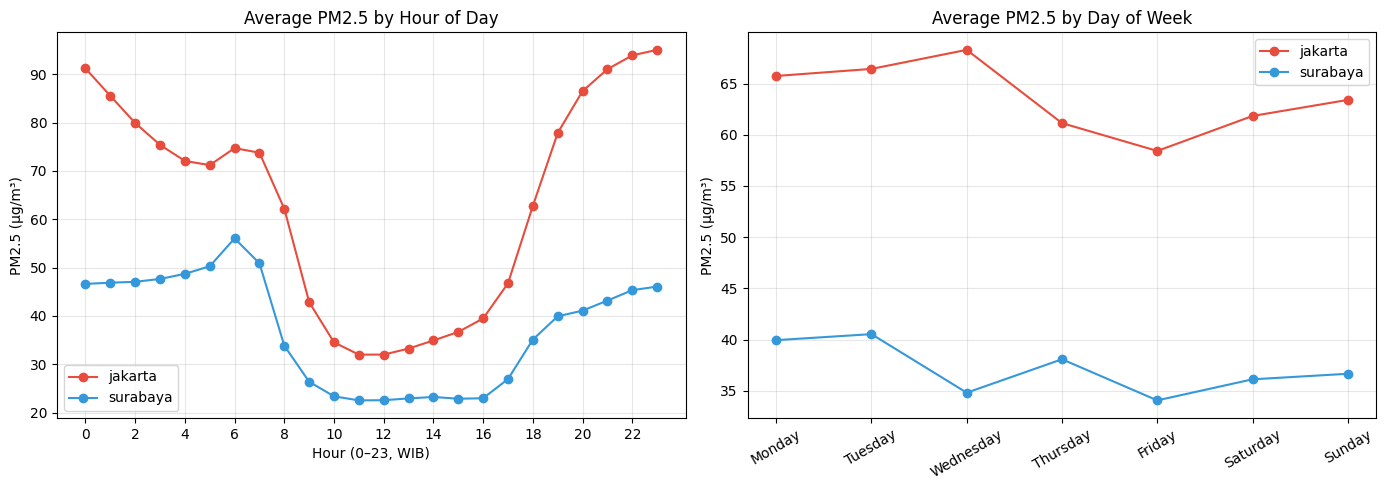

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["hour"] = df["timestamp"].dt.hour

for city in df["city"].unique():
    subset = df[df["city"] == city]
    hourly_mean = subset.groupby("hour")["pm2_5_ugm3"].mean()
    axes[0].plot(hourly_mean.index, hourly_mean.values,
                 marker="o", label=city, color=colors[city])

axes[0].set_title("Average PM2.5 by Hour of Day")
axes[0].set_xlabel("Hour (0–23, WIB)")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

df["dayofweek"] = df["timestamp"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

for city in df["city"].unique():
    subset = df[df["city"] == city]
    daily_mean = subset.groupby("dayofweek")["pm2_5_ugm3"].mean().reindex(day_order)
    axes[1].plot(daily_mean.index, daily_mean.values,
                 marker="o", label=city, color=colors[city])

axes[1].set_title("Average PM2.5 by Day of Week")
axes[1].set_xlabel("")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("""
=== EDA SUMMARY — Insight untuk Forecasting ===

TARGET VARIABLE:
  - pm2_5_ugm3 (PM2.5 sebagai proxy AQI utama)
  - pm10 di-drop karena korelasi = 1.00 dengan PM2.5 (redundant)

KEY PATTERNS FOUND:
  1. Hourly cycle (U-shape): tinggi subuh, rendah siang, tinggi malam
     → 'hour' adalah feature terpenting
  2. Seasonal trend: PM2.5 Jakarta naik signifikan April–Juni (musim kemarau)
     → rolling mean 7d/30d akan capture ini
  3. City effect: Jakarta 2× lebih kotor dari Surabaya dengan pola beda
     → 'city' harus jadi categorical feature
  4. Humidity inversely related to PM2.5 saat dipecah per kota
     → humidity sebagai weather feature

PLANNED FEATURES UNTUK MODEL:
  Time features  : hour, day_of_week, month, is_weekend
  Lag features   : pm2_5 lag 1h, 24h, 168h (1 minggu)
  Rolling stats  : rolling mean & std 3h, 24h, 7d
  Weather        : relative_humidity_pct, wind_speed_10m_kmh, temperature_2m_c
  Pollutant lags : no2 lag 1h (korelasi 0.85 dengan PM2.5)
  Categorical    : city (jakarta=0, surabaya=1)

ANOMALY NOTES:
  - CO max 17,354 µg/m³ (hourly spike, Jakarta) — real event, bukan error
  - PM2.5 max 207.7 µg/m³ — extreme pollution event, perlu flag di anomaly detection
""")



=== EDA SUMMARY — Insight untuk Forecasting ===

TARGET VARIABLE:
  - pm2_5_ugm3 (PM2.5 sebagai proxy AQI utama)
  - pm10 di-drop karena korelasi = 1.00 dengan PM2.5 (redundant)

KEY PATTERNS FOUND:
  1. Hourly cycle (U-shape): tinggi subuh, rendah siang, tinggi malam
     → 'hour' adalah feature terpenting
  2. Seasonal trend: PM2.5 Jakarta naik signifikan April–Juni (musim kemarau)
     → rolling mean 7d/30d akan capture ini
  3. City effect: Jakarta 2× lebih kotor dari Surabaya dengan pola beda
     → 'city' harus jadi categorical feature
  4. Humidity inversely related to PM2.5 saat dipecah per kota
     → humidity sebagai weather feature

PLANNED FEATURES UNTUK MODEL:
  Time features  : hour, day_of_week, month, is_weekend
  Lag features   : pm2_5 lag 1h, 24h, 168h (1 minggu)
  Rolling stats  : rolling mean & std 3h, 24h, 7d
  Weather        : relative_humidity_pct, wind_speed_10m_kmh, temperature_2m_c
  Pollutant lags : no2 lag 1h (korelasi 0.85 dengan PM2.5)
  Categorical    : 

In [8]:
df = df.sort_values(["city", "timestamp"]).reset_index(drop=True)

df["hour"]       = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek   
df["month"]      = df["timestamp"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print("Time features added:")
print(df[["timestamp", "city", "hour", "day_of_week", "month", "is_weekend"]].head(10))


Time features added:
            timestamp     city  hour  day_of_week  month  is_weekend
0 2026-01-01 00:00:00  jakarta     0            3      1           0
1 2026-01-01 01:00:00  jakarta     1            3      1           0
2 2026-01-01 02:00:00  jakarta     2            3      1           0
3 2026-01-01 03:00:00  jakarta     3            3      1           0
4 2026-01-01 04:00:00  jakarta     4            3      1           0
5 2026-01-01 05:00:00  jakarta     5            3      1           0
6 2026-01-01 06:00:00  jakarta     6            3      1           0
7 2026-01-01 07:00:00  jakarta     7            3      1           0
8 2026-01-01 08:00:00  jakarta     8            3      1           0
9 2026-01-01 09:00:00  jakarta     9            3      1           0


In [9]:
grp = df.groupby("city")["pm2_5_ugm3"]

df["pm2_5_lag_1h"]   = grp.shift(1)    
df["pm2_5_lag_24h"]  = grp.shift(24)   
df["pm2_5_lag_168h"] = grp.shift(168)  

df["no2_lag_1h"] = df.groupby("city")["nitrogen_dioxide_ugm3"].shift(1)

print("NaN per lag column:")
lag_cols = ["pm2_5_lag_1h", "pm2_5_lag_24h", "pm2_5_lag_168h", "no2_lag_1h"]
print(df[lag_cols].isnull().sum())

print("\nContoh lag (Jakarta, jam 0-3 Jan 1):")
print(df[df["city"] == "jakarta"][
    ["timestamp", "pm2_5_ugm3", "pm2_5_lag_1h", "pm2_5_lag_24h"]
].head(5))


NaN per lag column:
pm2_5_lag_1h        2
pm2_5_lag_24h      48
pm2_5_lag_168h    336
no2_lag_1h          2
dtype: int64

Contoh lag (Jakarta, jam 0-3 Jan 1):
            timestamp  pm2_5_ugm3  pm2_5_lag_1h  pm2_5_lag_24h
0 2026-01-01 00:00:00        36.3           NaN            NaN
1 2026-01-01 01:00:00        28.7          36.3            NaN
2 2026-01-01 02:00:00        21.8          28.7            NaN
3 2026-01-01 03:00:00        17.4          21.8            NaN
4 2026-01-01 04:00:00        14.5          17.4            NaN


In [10]:
def rolling_per_city(col, window, func="mean", min_periods=1):
    return df.groupby("city")[col].transform(
        lambda x: getattr(x.rolling(window, min_periods=min_periods), func)()
    )

df["pm2_5_roll_mean_3h"]  = rolling_per_city("pm2_5_ugm3", 3)
df["pm2_5_roll_mean_24h"] = rolling_per_city("pm2_5_ugm3", 24)
df["pm2_5_roll_mean_7d"]  = rolling_per_city("pm2_5_ugm3", 168)
df["pm2_5_roll_std_24h"]  = rolling_per_city("pm2_5_ugm3", 24, func="std", min_periods=2)

print("Rolling features added. Sample (Jakarta, row 20-26):")
print(df[df["city"] == "jakarta"][[
    "timestamp", "pm2_5_ugm3",
    "pm2_5_roll_mean_3h", "pm2_5_roll_mean_24h", "pm2_5_roll_std_24h"
]].iloc[20:27].to_string(index=False))


Rolling features added. Sample (Jakarta, row 20-26):
          timestamp  pm2_5_ugm3  pm2_5_roll_mean_3h  pm2_5_roll_mean_24h  pm2_5_roll_std_24h
2026-01-01 20:00:00        77.5           71.900000            31.233333           19.407250
2026-01-01 21:00:00        83.1           82.633333            33.590909           21.931385
2026-01-01 22:00:00        91.0           83.866667            36.086957           24.544214
2026-01-01 23:00:00        85.2           86.433333            38.133333           26.014037
2026-01-02 00:00:00        66.1           80.766667            39.375000           26.626699
2026-01-02 01:00:00        60.1           70.466667            40.683333           26.849867
2026-01-02 02:00:00        58.3           61.500000            42.204167           26.767363


In [11]:
df["city_encoded"] = (df["city"] == "surabaya").astype(int)

df_model = df.dropna().reset_index(drop=True)

feature_cols = [
    # time
    "hour", "day_of_week", "month", "is_weekend",
    # weather
    "temperature_2m_c", "relative_humidity_pct", "wind_speed_10m_kmh",
    # lags
    "pm2_5_lag_1h", "pm2_5_lag_24h", "pm2_5_lag_168h", "no2_lag_1h",
    # rolling
    "pm2_5_roll_mean_3h", "pm2_5_roll_mean_24h", "pm2_5_roll_mean_7d", "pm2_5_roll_std_24h",
    # categorical
    "city_encoded",
]
target_col = "pm2_5_ugm3"

print(f"Rows sebelum drop NaN : {len(df)}")
print(f"Rows setelah drop NaN : {len(df_model)}")
print(f"Rows yang hilang      : {len(df) - len(df_model)} (168 per kota × 2 = 336)")
print(f"\nJumlah features : {len(feature_cols)}")
print(f"Target          : {target_col}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

print(f"\nShape final (X, y):")
X = df_model[feature_cols]
y = df_model[target_col]
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")
print(f"\nNaN check di X: {X.isnull().sum().sum()} total NaN")


Rows sebelum drop NaN : 8304
Rows setelah drop NaN : 7968
Rows yang hilang      : 336 (168 per kota × 2 = 336)

Jumlah features : 16
Target          : pm2_5_ugm3

Feature list:
   1. hour
   2. day_of_week
   3. month
   4. is_weekend
   5. temperature_2m_c
   6. relative_humidity_pct
   7. wind_speed_10m_kmh
   8. pm2_5_lag_1h
   9. pm2_5_lag_24h
  10. pm2_5_lag_168h
  11. no2_lag_1h
  12. pm2_5_roll_mean_3h
  13. pm2_5_roll_mean_24h
  14. pm2_5_roll_mean_7d
  15. pm2_5_roll_std_24h
  16. city_encoded

Shape final (X, y):
  X: (7968, 16)
  y: (7968,)

NaN check di X: 0 total NaN
